# Multi-Asset Portfolio Analysis

## Role & Objective

I am a **Junior Multi-Asset Analyst** supporting a Portfolio Manager.

The goal is to analyze how a diversified portfolio performs, where its risks come from, and how its behavior changes under different market conditions.

Rather than analyzing an individual company or predicting stock prices, this project focuses on **portfolio-level decision-making across multiple asset classes**.

I will construct a hypothetical multi-asset portfolio consisting of:

* U.S. Equities (SPY)
* U.S. Treasury Bonds (IEF)
* International Equities (VXUS)
* Gold (GLD)

Using historical market and economic data, I will evaluate the portfolio's:

* Performance
* Risk exposure
* Diversification
* Resilience across different market environments

---

## Investment Scenario

Assume a Portfolio Manager is responsible for a **moderately risk-tolerant portfolio** with the following target allocation:

| Asset Class            | Target Weight |
| ---------------------- | ------------: |
| U.S. Equities          |           50% |
| U.S. Treasury Bonds    |           30% |
| International Equities |           10% |
| Gold                   |           10% |

---

## Key Questions

The analysis will answer the following questions:

1. **How has the portfolio performed historically?**
2. **Which assets have contributed most to portfolio returns?**
3. **Where is the portfolio's risk coming from?**
4. **How effective is diversification across the different asset classes?**
5. **How does portfolio behavior change during different market regimes?**
6. **How resilient is the portfolio to potential market shocks?**
7. **What portfolio positioning or rebalancing considerations emerge from the analysis?**

---

## Analytical Framework

The project will connect:

**Market Data → Asset Behavior → Portfolio Exposure → Risk → Investment Insight**


# Data

In [1]:
%pip install yfinance pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd

In [3]:
import datetime

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

## Market Datasets

In [5]:
tickers = ["SPY", "IEF", "VXUS", "GLD"]

In [6]:
prices = yf.download(
    tickers,
    start="2016-01-01",
    end="2026-08-01",
    auto_adjust=True
)


[*********************100%***********************]  4 of 4 completed


In [7]:
prices.head()

Price            Close                                          High  \
Ticker             GLD        IEF         SPY       VXUS         GLD   
Date                                                                   
2016-01-04  102.889999  83.205620  169.471558  32.494839  103.669998   
2016-01-05  103.180000  83.182076  169.758194  32.436207  103.459999   
2016-01-06  104.669998  83.684258  167.616867  31.886427  104.800003   
2016-01-07  106.150002  83.864716  163.595459  31.226717  106.239998   
2016-01-08  105.680000  84.076630  161.799713  30.860207  105.800003   

Price                                                Low             \
Ticker            IEF         SPY       VXUS         GLD        IEF   
Date                                                                  
2016-01-04  83.488099  169.479984  32.604790  102.489998  83.166384   
2016-01-05  83.331157  170.213440  32.502179  102.930000  83.040836   
2016-01-06  83.699948  168.662251  31.989049  103.930000  83.464553   
2016-01-07  83.864716  166.453426  31.578570  105.190002  83.503772   
2016-01-08  84.115859  165.112938  31.461284  105.040001  83.715685   

Price                                    Open                         \
Ticker             SPY       VXUS         GLD        IEF         SPY   
Date                                                                   
2016-01-04  167.422920  32.128328  103.129997  83.244849  169.024738   
2016-01-05  168.653790  32.252951  103.129997  83.150688  169.791911   
2016-01-06  166.588335  31.725161  104.370003  83.535170  167.212190   
2016-01-07  163.207647  31.175406  105.830002  83.794099  164.674573   
2016-01-08  161.513076  30.808895  105.480003  83.786302  164.556517   

Price                    Volume                               
Ticker           VXUS       GLD      IEF        SPY     VXUS  
Date                                                          
2016-01-04  32.604790   6440000  6183700  222353500  1497200  
2016-01-05  32.502179   3500300  2122800  110845800   651100  
2016-01-06  31.827784   9316600  1906100  152112600   991500  
2016-01-07  31.329342  11730400  3106000  213436100  1900800  
2016-01-08  31.461284   7678200  1783200  209817200   794700

In [8]:
prices = prices["Close"]
prices.head()

Ticker,GLD,IEF,SPY,VXUS
Date,,,,
2016-01-04,102.889999,83.205620,169.471558,32.494839
2016-01-05,103.180000,83.182076,169.758194,32.436207
2016-01-06,104.669998,83.684258,167.616867,31.886427
2016-01-07,106.150002,83.864716,163.595459,31.226717
2016-01-08,105.680000,84.076630,161.799713,30.860207


In [9]:
prices.isna().sum()

Ticker
GLD     0
IEF     0
SPY     0
VXUS    0
dtype: int64

In [10]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2659 entries, 2016-01-04 to 2026-07-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     2659 non-null   float64
 1   IEF     2659 non-null   float64
 2   SPY     2659 non-null   float64
 3   VXUS    2659 non-null   float64
dtypes: float64(4)
memory usage: 103.9 KB


In [11]:
returns= prices.pct_change().dropna()

In [12]:
returns.head()

Ticker,GLD,IEF,SPY,VXUS
Date,,,,
2016-01-05,0.002819,-0.000283,0.001691,-0.001804
2016-01-06,0.014441,0.006037,-0.012614,-0.016950
2016-01-07,0.014140,0.002156,-0.023992,-0.020689
2016-01-08,-0.004428,0.002527,-0.010977,-0.011737
2016-01-11,-0.008895,-0.003174,0.000990,0.002138


In [13]:
returns.mean()

Ticker
GLD     0.000536
IEF     0.000049
SPY     0.000621
VXUS    0.000420
dtype: float64

In [14]:
returns.std()

Ticker
GLD     0.010242
IEF     0.004130
SPY     0.011216
VXUS    0.010918
dtype: float64

## Download the datasets

In [15]:
returns.to_csv("daily_returns.csv")

In [16]:
prices.to_csv("prices.csv")

# Portfolio Performance

Hypothetical Portfolio

In [17]:
weights = {
    "SPY": 0.50,
    "IEF": 0.30,
    "VXUS": 0.10,
    "GLD": 0.10
}

In [18]:
sum(weights.values())

1.0

Calculate Daily Portfolio Returns

In [19]:
portfolio_returns = (
    returns["SPY"] * 0.50 +
    returns["IEF"] * 0.30 +
    returns["VXUS"] * 0.10 +
    returns["GLD"] * 0.10
)

In [20]:
portfolio_returns.head()

Date
2016-01-05    0.000862
2016-01-06   -0.004747
2016-01-07   -0.012004
2016-01-08   -0.006347
2016-01-11   -0.001133
dtype: float64

## Calculate cumulative portfolio performance

In [21]:
cumulative_returns = (1 + portfolio_returns).cumprod()

In [22]:
cumulative_returns.head()

Date
2016-01-05    1.000862
2016-01-06    0.996111
2016-01-07    0.984154
2016-01-08    0.977908
2016-01-11    0.976800
dtype: float64

In [23]:
initial_investment = 100000

portfolio_value = initial_investment * cumulative_returns

portfolio_value.tail()

Date
2026-07-27    286634.549416
2026-07-28    286648.706511
2026-07-29    283921.429817
2026-07-30    287623.441624
2026-07-31    287928.506905
dtype: float64

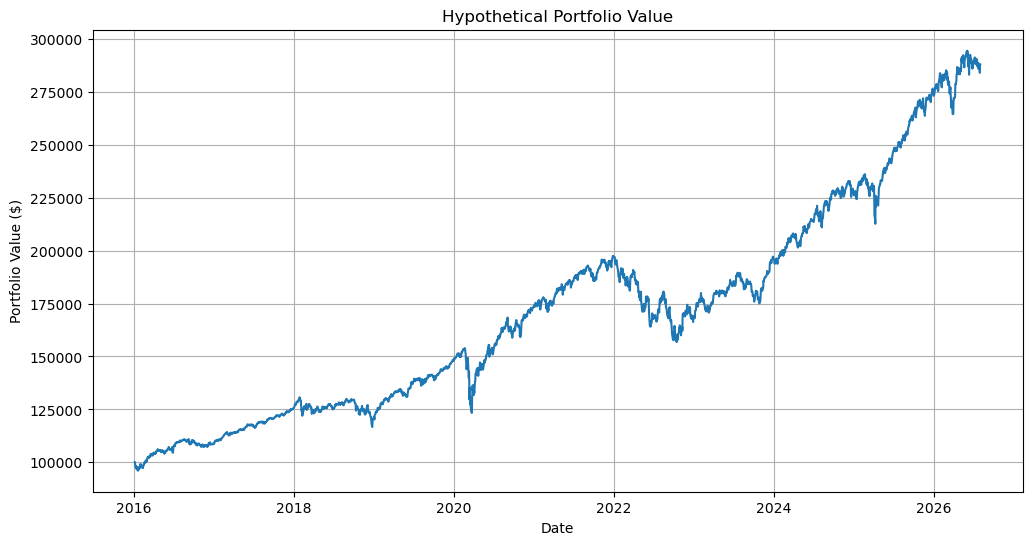

In [24]:

plt.figure(figsize=(12, 6))

plt.plot(portfolio_value)

plt.title("Hypothetical Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)

plt.show()

### **1. How has the portfolio performed historically?**

Between 2016 and mid-2026, the portfolio demonstrated strong long-term growth, nearly tripling its initial value from **\$100,000** to approximately **\$285,000**. While steady early expansion was interrupted by a sharp COVID-19 shock in early 2020 (dropping to **\$123,000**) and a market pullback throughout 2022 (bottoming near **\$158,000**), each downturn was followed by a robust recovery. Most notably, a powerful rally starting in early 2024 drove the portfolio to an all-time high near **\$295,000** before stabilizing at its current level.

## Compare the individual assets

In [25]:
asset_growth=(1+returns).cumprod()

In [26]:
asset_values= asset_growth*initial_investment

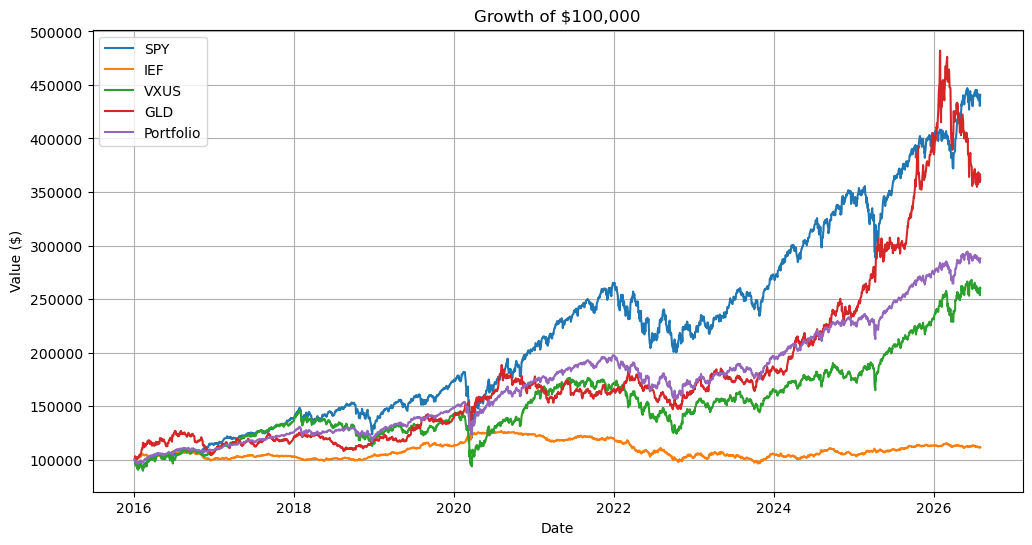

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(asset_values["SPY"], label="SPY")
plt.plot(asset_values["IEF"], label="IEF")
plt.plot(asset_values["VXUS"], label="VXUS")
plt.plot(asset_values["GLD"], label="GLD")
plt.plot(portfolio_value, label="Portfolio")

plt.title("Growth of $100,000")
plt.xlabel("Date")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True)

plt.show()

### **2. Which assets have contributed most to portfolio returns?**

* **Growth Engines:** **SPY** and **GLD** were the two dominant performers driving the combined **Portfolio (Purple Line)** up to its final level near **\$285,000**.
* **Risk Mitigation:** **IEF** and **VXUS** acted as stabilizing weights, reducing overall portfolio volatility relative to individual equities and gold spikes.

# Risk

## Volatility

In [28]:
daily_volatility = returns.std()

daily_volatility

Ticker
GLD     0.010242
IEF     0.004130
SPY     0.011216
VXUS    0.010918
dtype: float64

In [29]:
#Convert it to annualized volatility
annualized_volatility = returns.std() * (252 ** 0.5)
annualized_volatility

Ticker
GLD     0.162582
IEF     0.065558
SPY     0.178046
VXUS    0.173322
dtype: float64

In [30]:
portfolio_volatility = portfolio_returns.std() * (252 ** 0.5)

portfolio_volatility

0.10750861947262512

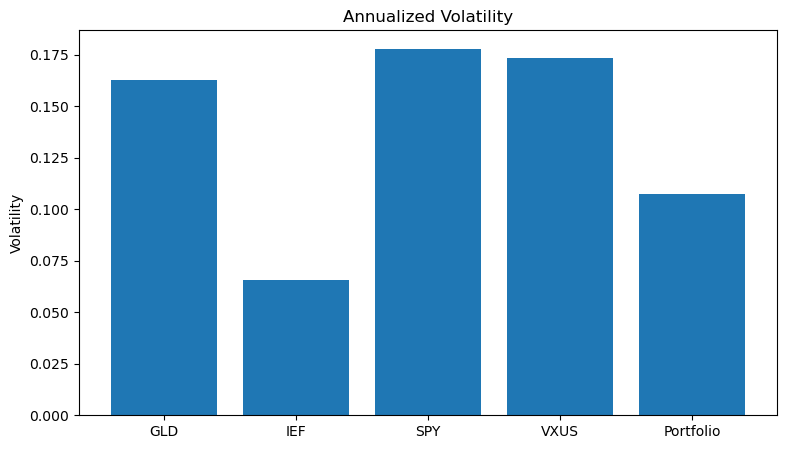

In [31]:
volatility = annualized_volatility.copy()
volatility["Portfolio"] = portfolio_volatility

plt.figure(figsize=(9, 5))

plt.bar(volatility.index, volatility.values)

plt.title("Annualized Volatility")
plt.ylabel("Volatility")

plt.show()

SPY (\~17.8%) and VXUS (\~17.3%) exhibit the highest standalone volatility, closely followed by GLD (\~16.3%).

IEF (\~6.5%) has the lowest standalone volatility.

Due to diversification across asset classes, overall Portfolio Volatility (\~10.7%) is significantly lower than that of SPY, VXUS, or GLD.

## Maximum Drawdown

In [32]:
cumulative = (1 + returns).cumprod()

In [33]:
running_peak = cumulative.cummax()

In [34]:
drawdown = (cumulative - running_peak) / running_peak

In [35]:
max_drawdown = drawdown.min()

max_drawdown

Ticker
GLD    -0.264045
IEF    -0.239248
SPY    -0.337173
VXUS   -0.359724
dtype: float64

In [36]:
portfolio_cumulative = (1 + portfolio_returns).cumprod()

In [37]:
portfolio_peak = portfolio_cumulative.cummax()


In [38]:
portfolio_drawdown = (
    portfolio_cumulative - portfolio_peak
) / portfolio_peak

In [39]:
portfolio_max_drawdown = portfolio_drawdown.min()
portfolio_max_drawdown

-0.20609994404629056

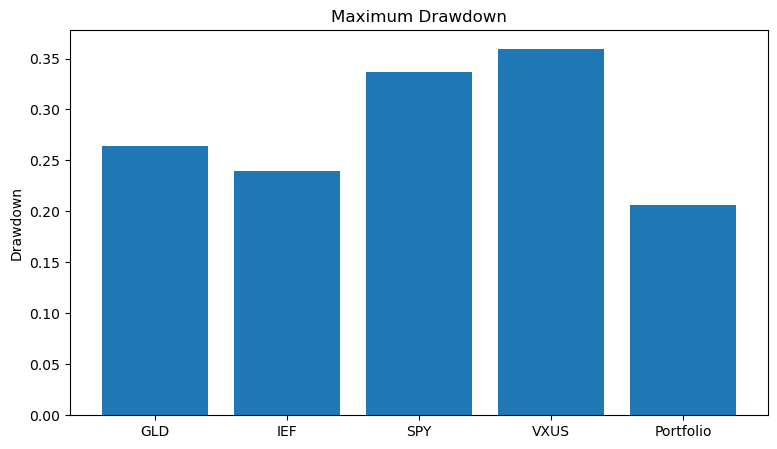

In [40]:
max_drawdowns = max_drawdown.copy()

max_drawdowns["Portfolio"] = portfolio_max_drawdown

plt.figure(figsize=(9, 5))

plt.bar(max_drawdowns.index, abs(max_drawdowns.values))

plt.title("Maximum Drawdown")
plt.ylabel("Drawdown")

plt.show()

VXUS (\~36%) and SPY (\~34%) experienced the deepest peak-to-trough losses.

GLD (\~26%) and IEF (\~24%) had moderate maximum drawdowns.

Portfolio Drawdown (\~21%) remains lower than any single component asset, demonstrating the protective effect of combining uncorrelated assets.

## Correlation

In [41]:
correlation = returns.corr()

correlation

Ticker,GLD,IEF,SPY,VXUS
Ticker,,,,
GLD,1.000000,0.335108,0.077168,0.216426
IEF,0.335108,1.000000,-0.127671,-0.071645
SPY,0.077168,-0.127671,1.000000,0.848262
VXUS,0.216426,-0.071645,0.848262,1.000000


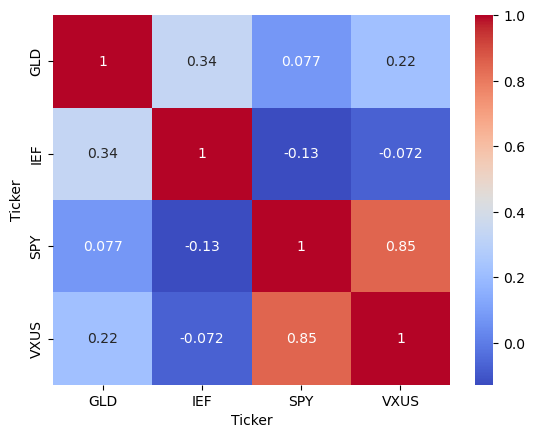

In [42]:
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()


* **SPY vs. VXUS (0.85 — High Positive): Move in Sync**  
  U.S. and international equities move in the same direction 85% of the time. Adding VXUS provides geographic exposure, but it will not protect the portfolio during a broad market crash.

* **SPY vs. IEF (-0.13 — Negative): The Shock Absorber**  
  Treasuries move inversely to U.S. stocks. When equities drop, bonds tend to hold firm or gain, softening overall portfolio drawdowns.

* **SPY vs. GLD (0.08 — Near Zero): Independent Operator**  
  Gold operates independently of U.S. equities. Its price movements are driven by separate macroeconomic factors, providing return potential without adding stock market risk.

* **GLD vs. IEF (0.34 — Moderate Positive): Shared Drivers**  
  Gold and Treasuries show a moderate connection because both react to broader economic signals like interest rate shifts and inflation expectations.

## Risk contribution

In [43]:
covariance = returns.cov() * 252

covariance

Ticker,GLD,IEF,SPY,VXUS
Ticker,,,,
GLD,0.026433,0.003572,0.002234,0.006099
IEF,0.003572,0.004298,-0.001490,-0.000814
SPY,0.002234,-0.001490,0.031701,0.026177
VXUS,0.006099,-0.000814,0.026177,0.030041


In [44]:
weights_vector = returns.columns.map(weights)

weights_vector

Index([0.1, 0.3, 0.5, 0.1], dtype='float64', name='Ticker')

In [45]:
portfolio_variance = (
    weights_vector @ covariance @ weights_vector
)

portfolio_volatility = portfolio_variance ** 0.5

In [46]:
portfolio_volatility

np.float64(0.10750861947262519)

In [47]:
marginal_contribution = covariance @ weights_vector

In [48]:
risk_contribution = (
    weights_vector * marginal_contribution
) / portfolio_volatility

In [49]:
risk_contribution_pct = (
    risk_contribution / risk_contribution.sum()
)

risk_contribution_pct

Ticker
GLD     0.047080
IEF     0.021284
SPY     0.789240
VXUS    0.142395
dtype: float64

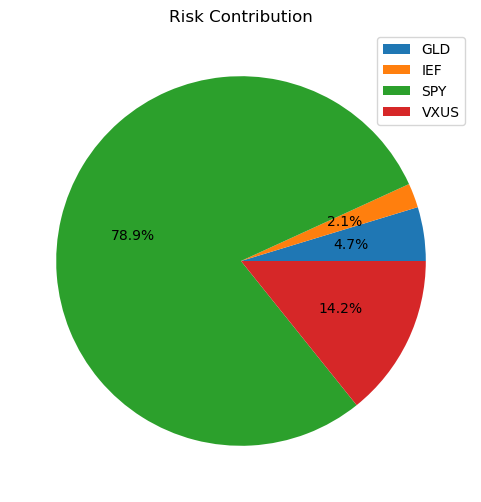

In [50]:
risk_contribution_pct.sort_values(ascending=False)
plt.figure(figsize=(11, 6))
plt.pie(risk_contribution_pct,  autopct="%1.1f%%")
plt.legend(risk_contribution_pct.index)
plt.title("Risk Contribution")
plt.show()

* SPY drives 78.9% of the portfolio's total risk.

* VXUS accounts for 14.2%, meaning equities collectively generate 93.1% of total portfolio risk.

* GLD contributes only 4.7% and IEF contributes 2.1% to overall portfolio risk.

In [70]:
risk_free_rate = 0.02 
sharpe_ratio = (portfolio_returns.mean() * 252 - risk_free_rate) / (portfolio_returns.std() * (252**0.5))

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

class sharpe_ratio(ABC):
    def __init__(self, returns, risk_free_rate=0.02, periods_per_year=252):
        self.returns = returns
        self.risk_free_rate = risk_free_rate
        self.periods_per_year = periods_per_year

    @abstractmethod
    def _risk_free_per_period(self):
        pass

    @abstractmethod
    def _annualized_volatility(self):
        pass

    @abstractmethod
    def calculate(self):
        pass

class daily_sharpe_ratio(sharpe_ratio):
    def _risk_free_per_period(self):
        return self.risk_free_rate / self.periods_per_year

    def _annualized_volatility(self):
        return self.returns.std() * np.sqrt(self.periods_per_year)

    def calculate(self):
        excess_return = self.returns.mean() - self._risk_free_per_period()
        vol = self._annualized_volatility()
        if isinstance(vol, pd.Series):
            vol = vol.replace(0, np.nan)
        elif vol == 0:
            return np.nan
        return excess_return / vol

portfolio_sharpe_ratio = daily_sharpe_ratio(portfolio_returns, risk_free_rate=0.02).calculate()
portfolio_sharpe_ratio

np.float64(0.8005630978033013)

### **3. Where is the portfolio's risk coming from?**

Portfolio risk is overwhelmingly concentrated in **U.S. Equities (SPY)**, which drives **78.9%** of total portfolio variance.

* **Primary Driver:** **SPY** generates **78.9%** of total portfolio risk contribution. When combined with **VXUS (14.2%)**, equity exposure drives **93.1%** of overall portfolio risk.
* **Secondary Drivers:** **GLD (4.7%)** and **IEF (2.1%)** contribute minimally to total portfolio risk despite their individual volatility levels.
* **Metric Interaction:** While standalone **Volatility** suggests similar risk across growth assets (**SPY: ~17.8%**, **VXUS: ~17.3%**, **GLD: ~16.3%**), evaluating **Risk Contribution** and **Correlation** proves that U.S. stock movements dominate actual portfolio fluctuations.

---

### **4. How effective is diversification across the different asset classes?**

Diversification is **highly effective at reducing overall volatility and maximum drawdowns**, though its protection depends heavily on which asset classes are compared:

* **Overall Downside Protection:** Combining asset classes successfully cushioned peak-to-trough tail risk-cutting the total **Portfolio Max Drawdown to ~21%**, compared to **~34%** for SPY and **~36%** for VXUS. Total **Portfolio Volatility (~10.7%)** was also significantly lower than any individual equity or gold holding.
* **Non-Equity Assets (GLD & IEF) - Highly Effective:**
  * **GLD** acts as an independent return engine with a near-zero correlation to SPY (**0.077**), delivering capital growth without piling onto stock market risk.
  * **IEF** serves as an effective stabilizer with a negative correlation to SPY (**-0.13**), cushioning the portfolio during equity downturns.
* **International Equities (VXUS) - Ineffective for Downside Protection:** Due to a strong positive correlation with SPY (**0.85**), VXUS offers minimal crash protection during broad market sell-offs, as both equity markets decline simultaneously.

#### **Summary Conclusion**
Diversification across these asset classes is **moderately-to-highly effective**. It preserves long-term compounding growth while cutting worst-case capital losses by roughly one-third compared to an all-equity strategy. However, because capital allocation remains heavily weighted toward equities, total portfolio risk is still overwhelmingly controlled by the U.S. stock market.

# Regime Analysis

In [51]:
monthly_returns = returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)

In [52]:
regime = pd.Series("Neutral", index=monthly_returns.index)
regime[monthly_returns["SPY"] > 0] = "Bull" #Stocks are rising, investors are optimistic
regime[monthly_returns["SPY"] < 0] = "Bear" #Stocks are falling, investors are defensive
regime[monthly_returns["IEF"] < 0] = "Rising_Rate" #Bonds may lose value


In [53]:
portfolio_monthly = portfolio_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)

In [54]:
regime_data = pd.DataFrame({
    "Portfolio": portfolio_monthly,
    "Regime": regime
})

In [55]:
regime_performance = regime_data.groupby("Regime")["Portfolio"].agg(
    ["mean", "std", "count"]
)

regime_performance

,mean,std,count
Regime,,,
Bear,-0.011136,0.022300,16
Bull,0.026265,0.018842,51
Rising_Rate,-0.000825,0.028271,60


### **5. How does portfolio behavior change during different market regimes?**

To evaluate how the multi-asset portfolio behaves under different market conditions, I analyzed performance across three regimes: equity bull markets, equity bear markets, and rising-rate environments.

The portfolio generated an average monthly return of **2.63% during bull markets**, indicating that the allocation maintained exposure to equity upside through its SPY and VXUS positions.

During equity bear markets, the portfolio declined by **1.11% on average**, which was lower than the losses typically experienced by equity-focused assets. This suggests that the inclusion of fixed income (IEF) and alternative assets (GLD) helped reduce downside exposure during periods of market stress.

During rising-rate environments, the portfolio experienced an average return of **-0.08%**, with higher volatility compared with other regimes. This highlights the sensitivity of the Treasury allocation (IEF) to changing interest-rate conditions, while other asset classes helped offset some of the impact.

Overall, the regime analysis demonstrates that the portfolio behaved differently across market environments. The allocation captured growth during favorable equity conditions while providing downside protection during weaker equity periods, illustrating the benefits and trade-offs of multi-asset diversification.

# Stress Testing

### Scenario 1: Equity Market Crash

#### Assumption
A severe stock selloff happens:

| Asset | Shock |
| :--- | :--- |
| **SPY** | -20% |
| **VXUS** | -25% |
| **IEF** | +5% |
| **GLD** | +10% |



In [56]:
equity_crash = {
    "SPY": -0.20,
    "IEF": 0.05,
    "VXUS": -0.25,
    "GLD": 0.10
}

In [57]:
equity_crash_result = sum(weights[asset] * equity_crash[asset] for asset in weights)

In [58]:
equity_crash_result*100

-10.0

### Scenario 2: Rising Interest Rate Shock

#### Assumption
Asset shock performance during a rapid rate hike environment:

| Asset | Shock |
| :--- | :--- |
| **SPY** | -10% |
| **VXUS** | -12% |
| **IEF** | -8% |
| **GLD** | +3% |

In [59]:
rate_shock = {
    "SPY": -0.10,
    "IEF": -0.08,
    "VXUS": -0.12,
    "GLD": 0.03
}

In [60]:
rate_shock_result = sum(weights[asset] * rate_shock[asset] for asset in weights)

In [61]:
rate_shock_result * 100

-8.3

### Scenario 3: Global Risk-Off Event

#### Assumption
An extreme, widespread flight to quality across global markets:

| Asset | Shock |
| :--- | :--- |
| **SPY** | -30% |
| **VXUS** | -35% |
| **IEF** | +10% |
| **GLD** | +15% |

In [62]:
risk_off = {
    "SPY": -0.30,
    "IEF": 0.10,
    "VXUS": -0.35,
    "GLD": 0.15
}

In [63]:
risk_off_result = sum(weights[asset] * risk_off[asset] for asset in weights)

In [64]:
risk_off_result * 100

-13.999999999999998

In [65]:
stress_results = pd.DataFrame({
    "Scenario": [
        "Equity Crash",
        "Rate Shock",
        "Global Risk-Off"
    ],
    "Portfolio Impact": [
        equity_crash_result,
        rate_shock_result,
        risk_off_result
    ]
})


In [66]:
stress_results["Portfolio Impact"] = stress_results["Portfolio Impact"] * 100

In [67]:
stress_results

,Scenario,Portfolio Impact
0,Equity Crash,-10.0
1,Rate Shock,-8.3
2,Global Risk-Off,-14.0


### **6. How resilient is the portfolio to potential market shocks?**

Stress testing was conducted to evaluate portfolio resilience under three hypothetical market scenarios: an equity market crash, a rising-rate shock, and a global risk-off event.

The equity crash scenario resulted in a portfolio decline of **10.0%**, demonstrating that the allocation to fixed income and gold provided downside protection compared with a portfolio concentrated entirely in equities.

The rising-rate scenario produced an **8.3% decline**, highlighting the sensitivity of the portfolio's Treasury allocation to interest-rate movements. While bonds generally provide diversification benefits, they may lose value during periods of increasing interest rates.

The global risk-off scenario represented the most severe stress case, resulting in a **14.0% decline**. Although equity exposure remained the primary driver of losses, defensive allocations to IEF and GLD helped reduce the overall impact.

Overall, the stress test demonstrates that the portfolio benefits from diversification during equity-driven market downturns but remains exposed to environments where multiple asset classes decline simultaneously.

### **7. What portfolio positioning or rebalancing considerations emerge from the analysis?**

Risk contribution analysis revealed that the portfolio's risk exposure is highly concentrated in equities. Although SPY represents 50% of the portfolio allocation, it contributes approximately 78.9% of total portfolio risk, making U.S. equities the primary driver of portfolio volatility.

In comparison, IEF represents 30% of portfolio weight but contributes only 2.1% of total risk due to its lower volatility and relatively low correlation with equity assets. GLD also provides diversification benefits, contributing 4.7% of portfolio risk despite a 10% allocation.

These results suggest that the portfolio is more equity-sensitive than the allocation weights alone indicate. While the current allocation benefits from meaningful diversification through fixed income and gold exposure, portfolio managers should monitor equity concentration and evaluate whether the current risk profile aligns with investment objectives.

Potential rebalancing considerations include adjusting equity exposure if a lower-risk profile is desired, while maintaining exposure to diversifying assets that reduce overall portfolio volatility. Rather than reacting to short-term market movements, systematic rebalancing can help maintain the intended risk structure over time.

### **Key Findings**




* Diversification reduced annualized volatility compared with individual equity assets.
* Although SPY represented 50% of portfolio weight, it contributed nearly 79% of total portfolio risk, indicating that equity exposure dominated the portfolio's risk profile.
* Treasury bonds and gold helped reduce losses during equity stress but provided less protection in rising-rate environments.
* The portfolio remained resilient under multiple hypothetical stress scenarios, illustrating the benefits and limitations of a diversified allocation.